# Part 2: RFM Customer Segmentation & Retention Strategy

In this notebook, we calculate Recency, Frequency, and Monetary (RFM) metrics from raw orders.
We merge these with non-RFM features: loyalty tier, returns, support ticket counts, and discounts.
We then apply an advanced segmentation system to identify customer risk groups and save the final table to `segments.csv`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

data_dir = "./dataset"


In [2]:
customers = pd.read_csv(os.path.join(data_dir, "customers.csv"))
orders = pd.read_csv(os.path.join(data_dir, "orders.csv"))
support = pd.read_csv(os.path.join(data_dir, "support_tickets.csv"))
labels = pd.read_csv(os.path.join(data_dir, "churn_labels.csv"))
interventions = pd.read_csv(os.path.join(data_dir, "intervention_history.csv"))


## 1. Outlier & Duplicate Treatment

From our Part 1 audit, we clean:
1. Exact duplicates in `orders.csv` ending in `_DUP`.
2. Outlier order value `ORD004428` for customer `CUST01295` (from 10,643.82 to 967.62 INR).
3. Leakage check: filter out post-snapshot transactions (`order_date > 2025-09-30`).


In [3]:
# Drop duplicate orders
orders_cleaned = orders[~orders['order_id'].str.endswith('_DUP', na=False)].copy()

# Correct the CUST01295 decimal outlier
orders_cleaned.loc[orders_cleaned['order_id'] == 'ORD004428', 'gross_amount'] = 967.62

# Keep only pre-snapshot orders
orders_pre = orders_cleaned[orders_cleaned['order_date'] <= '2025-09-30'].copy()
orders_pre['order_date'] = pd.to_datetime(orders_pre['order_date'])

print("Raw order count:", len(orders))
print("Pre-snapshot cleaned order count:", len(orders_pre))


Raw order count: 10009
Pre-snapshot cleaned order count: 8128


## 2. RFM Feature Computation

We define:
*   **Recency:** Days between snapshot date `2025-09-30` and the customer's last order date.
*   **Frequency:** Unique orders placed in the 180 days before snapshot.
*   **Monetary:** Total gross spend in the 180 days before snapshot.


In [4]:
ref_date = pd.to_datetime('2025-09-30')
start_date_180d = ref_date - pd.Timedelta(days=180)

orders_180d = orders_pre[orders_pre['order_date'] >= start_date_180d]

# Recency
recency = orders_pre.groupby('customer_id')['order_date'].max().reset_index()
recency['recency_days'] = (ref_date - recency['order_date']).dt.days

# Frequency
frequency = orders_180d.groupby('customer_id')['order_id'].nunique().reset_index(name='frequency_180d')

# Monetary
monetary = orders_180d.groupby('customer_id')['gross_amount'].sum().reset_index(name='monetary_180d')

# Average discount and return rate
discount = orders_180d.groupby('customer_id')['discount_pct'].mean().reset_index(name='avg_discount_pct_180d')
returns = orders_180d.groupby('customer_id')['returned'].mean().reset_index(name='return_rate_180d')
ratings = orders_180d.groupby('customer_id')['rating'].mean().reset_index(name='avg_rating_180d')

# Join base df
rfm = pd.DataFrame({'customer_id': customers['customer_id']})
rfm = rfm.merge(recency[['customer_id', 'recency_days']], on='customer_id', how='left')
rfm = rfm.merge(frequency, on='customer_id', how='left')
rfm = rfm.merge(monetary, on='customer_id', how='left')
rfm = rfm.merge(discount, on='customer_id', how='left')
rfm = rfm.merge(returns, on='customer_id', how='left')
rfm = rfm.merge(ratings, on='customer_id', how='left')

# Fill NaN values for inactive customers
rfm['recency_days'] = rfm['recency_days'].fillna(999)
rfm['frequency_180d'] = rfm['frequency_180d'].fillna(0)
rfm['monetary_180d'] = rfm['monetary_180d'].fillna(0.0)
rfm['avg_discount_pct_180d'] = rfm['avg_discount_pct_180d'].fillna(0.0)
rfm['return_rate_180d'] = rfm['return_rate_180d'].fillna(0.0)

print(rfm.head())


  customer_id  recency_days  frequency_180d  monetary_180d  \
0   CUST00001           107             1.0         362.73   
1   CUST00002            40             1.0         581.00   
2   CUST00003           171             1.0         649.98   
3   CUST00004           131             1.0        1604.04   
4   CUST00005            38             3.0        1781.90   

   avg_discount_pct_180d  return_rate_180d  avg_rating_180d  
0                   0.23               0.0              3.0  
1                   0.23               0.0              4.0  
2                   0.47               0.0              2.0  
3                   0.16               0.0              2.0  
4                   0.48               0.0              1.0  


## 3. Integrating Non-RFM Behavioral & Support Signals

We join days since signup and support ticket features (ticket counts, negative sentiment rates).


In [5]:
# Merge days since signup
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
customers['days_since_signup'] = (ref_date - customers['signup_date']).dt.days
rfm = rfm.merge(customers[['customer_id', 'days_since_signup']], on='customer_id')

# Support tickets aggregation
support_agg = support.groupby('customer_id').agg(
    ticket_count_90d=('ticket_id', 'count'),
    negative_ticket_rate_90d=('sentiment_score', lambda x: (x < 0).mean())
).reset_index()

rfm = rfm.merge(support_agg, on='customer_id', how='left')
rfm['ticket_count_90d'] = rfm['ticket_count_90d'].fillna(0)
rfm['negative_ticket_rate_90d'] = rfm['negative_ticket_rate_90d'].fillna(0.0)

print(rfm.head())


  customer_id  recency_days  frequency_180d  monetary_180d  \
0   CUST00001           107             1.0         362.73   
1   CUST00002            40             1.0         581.00   
2   CUST00003           171             1.0         649.98   
3   CUST00004           131             1.0        1604.04   
4   CUST00005            38             3.0        1781.90   

   avg_discount_pct_180d  return_rate_180d  avg_rating_180d  \
0                   0.23               0.0              3.0   
1                   0.23               0.0              4.0   
2                   0.47               0.0              2.0   
3                   0.16               0.0              2.0   
4                   0.48               0.0              1.0   

   days_since_signup  ticket_count_90d  negative_ticket_rate_90d  
0                524               2.0                       0.5  
1                121               1.0                       0.0  
2                206               0.0         

## 4. Advanced Segmentation Rules

We define 8 segments combining RFM with discount sensitivity and support complains:
1.  **High-Value Unhappy:** High spend (> 1500) and support complaints/low ratings.
2.  **Champions:** Recent, frequent, and high spend.
3.  **Loyal Customers:** Recent, active, and moderate spend.
4.  **New Customers:** Signed up recently, 1 order, recent purchase.
5.  **At-Risk:** High past value, dormant for 60-120 days.
6.  **Discount-Sensitive:** High discount percentage, active.
7.  **Dormant:** Inactive for over 120 days.
8.  **About to Churn:** Default.


In [6]:
def assign_segment(row):
    if row['monetary_180d'] > 1500 and (row['ticket_count_90d'] >= 2 or row['negative_ticket_rate_90d'] > 0.5 or row['avg_rating_180d'] <= 2.5):
        return 'High-Value Unhappy'
    if row['recency_days'] <= 30 and row['frequency_180d'] >= 3 and row['monetary_180d'] > 1500:
        return 'Champions'
    if row['recency_days'] <= 60 and row['frequency_180d'] >= 2 and row['monetary_180d'] > 800:
        return 'Loyal Customers'
    if row['days_since_signup'] <= 45 and row['frequency_180d'] == 1 and row['recency_days'] <= 30:
        return 'New Customers'
    if row['recency_days'] > 60 and row['recency_days'] <= 120 and (row['frequency_180d'] >= 2 or row['monetary_180d'] > 1000):
        return 'At-Risk'
    if row['avg_discount_pct_180d'] >= 0.25 and row['recency_days'] <= 90:
        return 'Discount-Sensitive'
    if row['recency_days'] > 120:
        return 'Dormant'
    return 'About to Churn'

rfm['segment_name'] = rfm.apply(assign_segment, axis=1)

# Write output csv
rfm[['customer_id', 'segment_name', 'recency_days', 'frequency_180d', 'monetary_180d', 'ticket_count_90d', 'return_rate_180d', 'avg_discount_pct_180d']].to_csv('segments.csv', index=False)
print("segments.csv output successfully.")


segments.csv output successfully.


## 5. Segment Summaries and Visualization

                    count  mean_recency  mean_frequency  mean_monetary  \
segment_name                                                             
Dormant               635    196.033071        0.651969     455.157858   
At-Risk               247     87.271255        1.979757    1494.895668   
About to Churn        290     62.279310        1.013793     653.380828   
Discount-Sensitive    349     40.862464        1.074499     626.705444   
High-Value Unhappy    421     49.351544        3.042755    2576.715297   
Loyal Customers       302     27.897351        2.311258    1552.412848   
New Customers         112     14.080357        1.000000     792.723304   
Champions              44     12.818182        3.727273    2785.357500   

                    mean_tickets  churn_rate  
segment_name                                  
Dormant                 0.661417    0.894488  
At-Risk                 0.680162    0.506073  
About to Churn          0.534483    0.489655  
Discount-Sensitive      

C:\Users\ditsd\AppData\Local\Temp\ipykernel_20024\3373325561.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm_vis, y='segment_name', order=order_segs, palette='viridis')


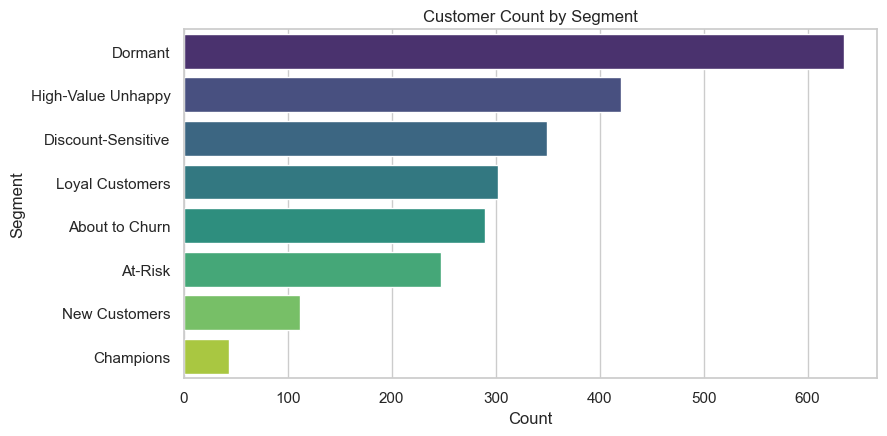

C:\Users\ditsd\AppData\Local\Temp\ipykernel_20024\3373325561.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary.reset_index(), x='churn_rate', y='segment_name', palette='Reds_r')


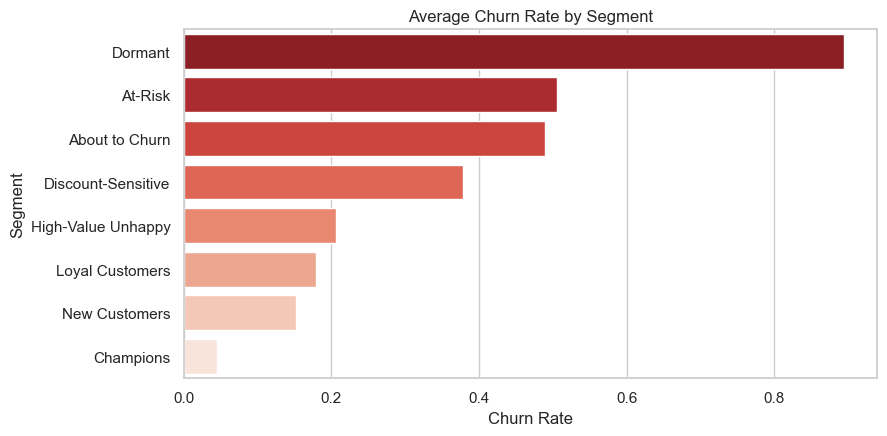

In [7]:
# Merge labels to compute churn rates per segment
rfm_vis = rfm.merge(labels[['customer_id', 'churn_next_60d']], on='customer_id')

# Segment summaries
summary = rfm_vis.groupby('segment_name').agg(
    count=('customer_id', 'count'),
    mean_recency=('recency_days', 'mean'),
    mean_frequency=('frequency_180d', 'mean'),
    mean_monetary=('monetary_180d', 'mean'),
    mean_tickets=('ticket_count_90d', 'mean'),
    churn_rate=('churn_next_60d', 'mean')
).sort_values('churn_rate', ascending=False)
print(summary)

# Plot sizes
plt.figure(figsize=(9, 4.5))
order_segs = rfm_vis['segment_name'].value_counts().index
ax = sns.countplot(data=rfm_vis, y='segment_name', order=order_segs, palette='viridis')
plt.title('Customer Count by Segment')
plt.xlabel('Count')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

# Plot churn rates
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=summary.reset_index(), x='churn_rate', y='segment_name', palette='Reds_r')
plt.title('Average Churn Rate by Segment')
plt.xlabel('Churn Rate')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()
